   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 3.0 MB/s eta 0:00:00
GAUSSIAN HMM — NIFTY 50 MARKET REGIME DETECTION

REGIME STATISTICS
 State  Observations  Mean Return (%)  Volatility (%)  Min Return (%)  Max Return (%)
     2          1317         0.104667        9.341003       -2.198793        2.066817
     0          1344        -0.001800       16.619349       -3.763569        3.818307
     1            46        -0.164797       70.895874      -12.980466        8.763210

TRANSITION MATRIX
         State 0  State 1  State 2
State 0   0.9671   0.0090   0.0239
State 1   0.1723   0.8277   0.0000
State 2   0.0202   0.0000   0.9798

INITIAL STATE PROBABILITIES
State 0    1.0
State 1    0.0
State 2    0.0
dtype: float64

CURRENT MARKET REGIME
-----------------------------------------------------------------
Date: 2025-12-31
Regime: Low Volatility

Current State Probabilities:
State 0: 4.27%
State 1: 

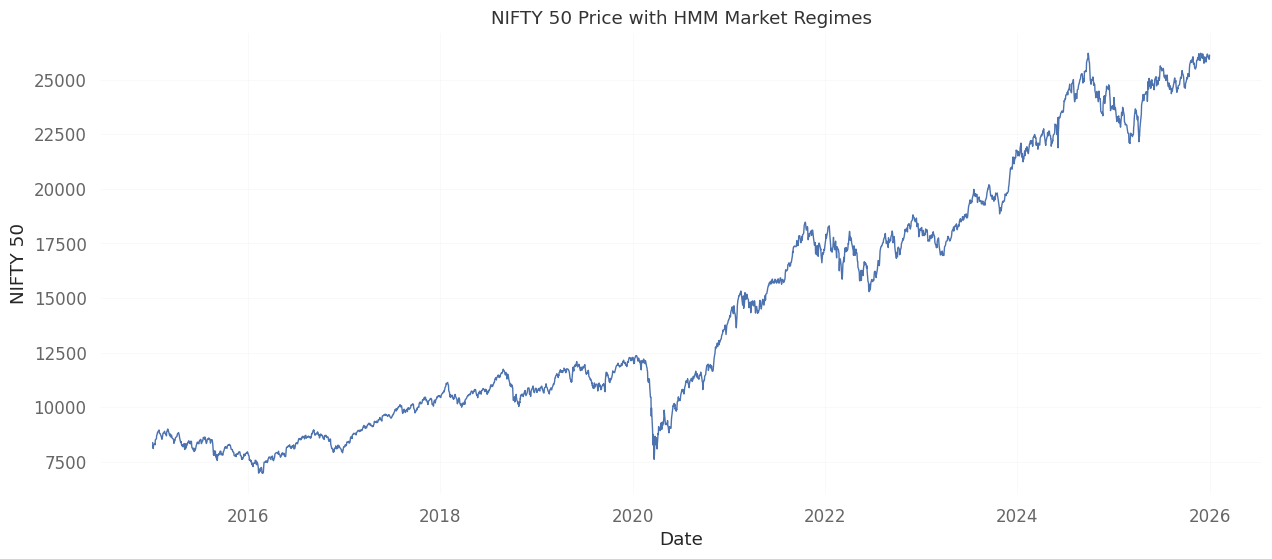

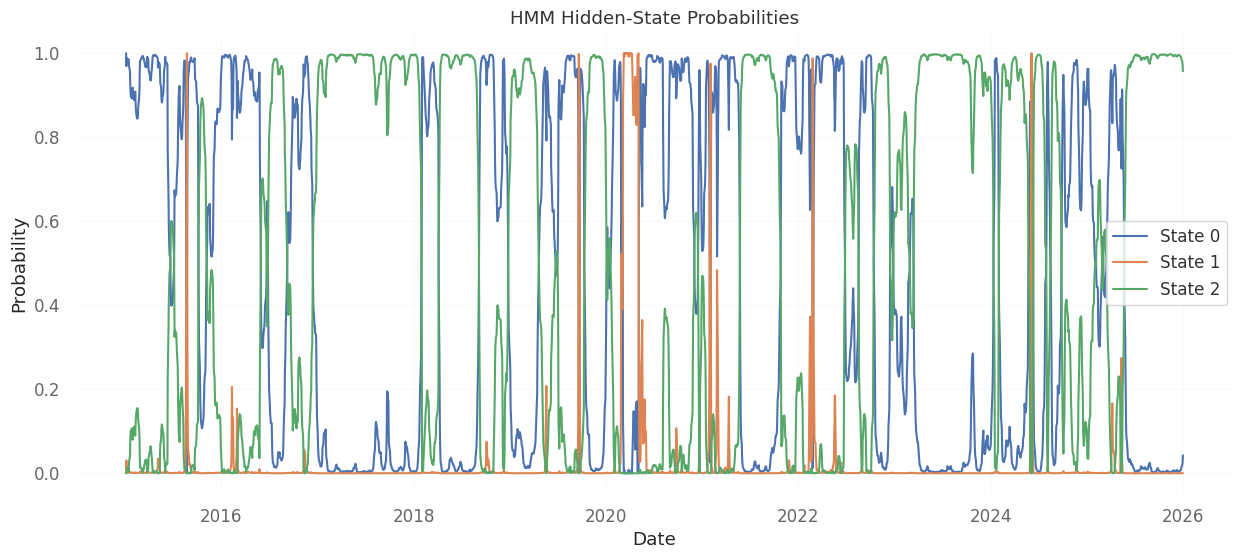

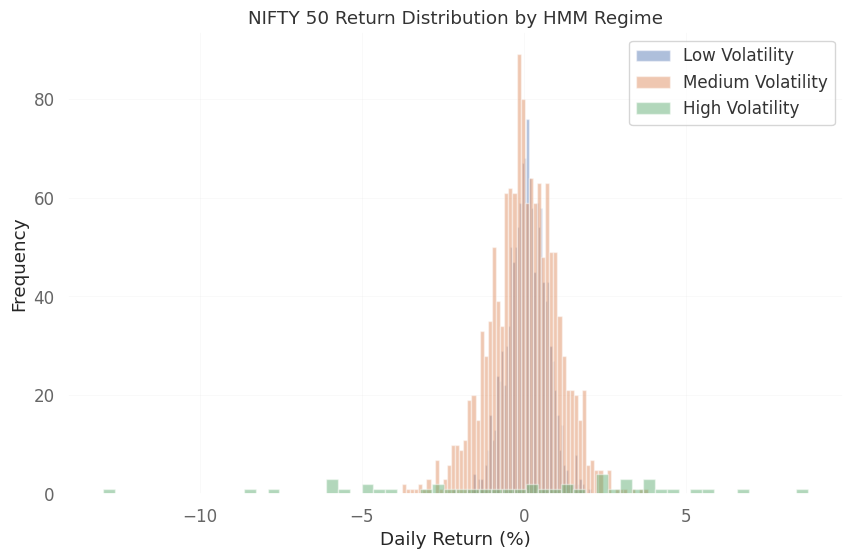


Saved: NIFTY50_HMM_Regime_Detection.csv


In [1]:
# ============================================================
# PROJECT 1 — GAUSSIAN HMM FOR NIFTY 50 MARKET REGIME DETECTION
# ============================================================

!pip -q install yfinance hmmlearn quantstats

import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import quantstats as qs

from google.colab import files
from hmmlearn.hmm import GaussianHMM

# ------------------------------------------------------------
# 1. DOWNLOAD NIFTY 50 DATA
# ------------------------------------------------------------
ticker = "^NSEI"

df = yf.download(
    ticker,
    start="2015-01-01",
    end="2026-01-01",
    auto_adjust=True,
    progress=False
)

# Handle yfinance MultiIndex
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df[["Close"]].dropna()

# ------------------------------------------------------------
# 2. CALCULATE RETURNS
# ------------------------------------------------------------
df["Return"] = df["Close"].pct_change()
df["Log_Return"] = np.log(df["Close"] / df["Close"].shift(1))

df = df.dropna()

# HMM works better with scaled observations
X = df[["Log_Return"]].values * 100

# ------------------------------------------------------------
# 3. FIT GAUSSIAN HMM
# ------------------------------------------------------------
n_states = 3

model = GaussianHMM(
    n_components=n_states,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

model.fit(X)

# Hidden state for every observation
df["State"] = model.predict(X)

# State probabilities
state_probs = model.predict_proba(X)

for i in range(n_states):
    df[f"State_{i}_Prob"] = state_probs[:, i]

# ------------------------------------------------------------
# 4. ANALYZE EACH REGIME
# ------------------------------------------------------------
regime_stats = []

for state in range(n_states):
    data = df[df["State"] == state]["Return"]

    regime_stats.append({
        "State": state,
        "Observations": len(data),
        "Mean Return (%)": data.mean() * 100,
        "Volatility (%)": data.std() * np.sqrt(252) * 100,
        "Min Return (%)": data.min() * 100,
        "Max Return (%)": data.max() * 100
    })

regime_stats = pd.DataFrame(regime_stats)

# Sort regimes by volatility
regime_stats = regime_stats.sort_values(
    "Volatility (%)"
).reset_index(drop=True)

# Map original states to intuitive regime labels
state_order = regime_stats["State"].tolist()

labels = ["Low Volatility", "Medium Volatility", "High Volatility"]

state_mapping = {
    state_order[i]: labels[i]
    for i in range(n_states)
}

df["Regime"] = df["State"].map(state_mapping)

# ------------------------------------------------------------
# 5. TRANSITION MATRIX
# ------------------------------------------------------------
transition_matrix = pd.DataFrame(
    model.transmat_,
    index=[f"State {i}" for i in range(n_states)],
    columns=[f"State {i}" for i in range(n_states)]
)

# ------------------------------------------------------------
# 6. REGIME SUMMARY
# ------------------------------------------------------------
print("=" * 65)
print("GAUSSIAN HMM — NIFTY 50 MARKET REGIME DETECTION")
print("=" * 65)

print("\nREGIME STATISTICS")
print(regime_stats.to_string(index=False))

print("\nTRANSITION MATRIX")
print(transition_matrix.round(4))

print("\nINITIAL STATE PROBABILITIES")
print(
    pd.Series(
        model.startprob_,
        index=[f"State {i}" for i in range(n_states)]
    ).round(4)
)

# ------------------------------------------------------------
# 7. CURRENT REGIME
# ------------------------------------------------------------
latest_state = df["State"].iloc[-1]
latest_regime = df["Regime"].iloc[-1]

print("\nCURRENT MARKET REGIME")
print("-" * 65)
print(f"Date: {df.index[-1].date()}")
print(f"Regime: {latest_regime}")

print("\nCurrent State Probabilities:")
for i in range(n_states):
    print(
        f"State {i}: "
        f"{df[f'State_{i}_Prob'].iloc[-1] * 100:.2f}%"
    )

# ------------------------------------------------------------
# 8. REGIME VISUALIZATION
# ------------------------------------------------------------
plt.figure(figsize=(15, 6))

plt.plot(
    df.index,
    df["Close"],
    linewidth=1
)

plt.title("NIFTY 50 Price with HMM Market Regimes")
plt.xlabel("Date")
plt.ylabel("NIFTY 50")

plt.grid(alpha=0.25)
plt.show()

# ------------------------------------------------------------
# 9. HIDDEN STATE PROBABILITIES
# ------------------------------------------------------------
plt.figure(figsize=(15, 6))

for i in range(n_states):
    plt.plot(
        df.index,
        df[f"State_{i}_Prob"],
        label=f"State {i}"
    )

plt.title("HMM Hidden-State Probabilities")
plt.xlabel("Date")
plt.ylabel("Probability")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# ------------------------------------------------------------
# 10. REGIME RETURN DISTRIBUTION
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

for regime in labels:
    data = df[df["Regime"] == regime]["Return"] * 100
    plt.hist(
        data,
        bins=60,
        alpha=0.45,
        label=regime
    )

plt.title("NIFTY 50 Return Distribution by HMM Regime")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# ------------------------------------------------------------
# 11. EXPORT RESULTS
# ------------------------------------------------------------
output = df[
    [
        "Close",
        "Return",
        "Log_Return",
        "State",
        "Regime",
        "State_0_Prob",
        "State_1_Prob",
        "State_2_Prob"
    ]
].copy()

output.to_csv("NIFTY50_HMM_Regime_Detection.csv")

print("\nSaved: NIFTY50_HMM_Regime_Detection.csv")